# Rosei Interband Model for $\varepsilon_2(\omega)$ of Gold

We reproduce the interband contribution to the imaginary dielectric function $\varepsilon_2(\omega)$ of gold, following the critical-point model of Guerrisi, Rosei & Winsemius (*Phys. Rev. B* **12**, 557, 1975).

The model expands the band structure to second order around two critical points in the fcc Brillouin zone:
- **X-point** — an $M_1$ saddle-point singularity (6 equivalent points)
- **L-point** — an $M_0$ minimum singularity (8 equivalent points)

The full model is:

$$
\varepsilon_2(\omega) = \frac{\text{Scale}}{\omega^2}\Big[\,|P_X|^2\, N_X\, J_X(\omega,T) \;+\; |P_L|^2\, N_L\, J_L(\omega,T)\Big] + \frac{A_D}{\omega^3}
$$

where $J_P(\omega,T)$ is the thermally-weighted joint density of states at critical point $P$.

In [18]:
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt

# ── Physical constants ──────────────────────────────────────────
kB = 8.617e-5   # Boltzmann constant [eV / K]
C  = 3.81       # ℏ²/(2mₑ)  [eV·Å²]

# ── Critical-point multiplicities ──────────────────────────────
N_X = 6   # X: 12 square faces of the BZ, each shared by 2 zones
N_L = 8   # L: 8 hexagonal faces, each fully inside one zone

## Band dispersion near the critical points

Near each critical point we expand the conduction ($c$) and valence ($v$) bands to second order in $\mathbf{k}$, measured from the critical point. The wave-vector is split into perpendicular ($k_\perp$) and parallel ($k_\parallel$) components relative to the $\Gamma$–X or $\Gamma$–L symmetry axis.

### X-point ($M_1$ saddle)

$$
E_c^X(\mathbf{k}) = E_{0c} + A_c\, k_\perp^2 - B_c\, k_\parallel^2, \qquad
E_v^X(\mathbf{k}) = E_{0v} - A_v\, k_\perp^2 - B_v\, k_\parallel^2
$$

The **opposite signs** on $k_\perp^2$ in $E_c$ make this a saddle point: the transition energy $\hbar\omega(\mathbf{k}) = E_c - E_v$ can equal $E_g$ along a *line* in $\mathbf{k}$-space, not just a single point. This means transitions are allowed **below** the gap energy — the hallmark of an $M_1$ singularity.

### L-point ($M_0$ minimum)

$$
E_c^L(\mathbf{k}) = E_{0c} + A_c\, k_\perp^2 + B_c\, k_\parallel^2, \qquad
E_v^L(\mathbf{k}) = E_{0v} - A_v\, k_\perp^2 - B_v\, k_\parallel^2
$$

All curvatures push $E_c - E_v$ **upward** away from the critical point — an ordinary band gap with no sub-gap transitions.

### Derived quantities

The transition energy is $\hbar\omega = E_g + \bar{A}\,k_\perp^2 \pm \bar{B}\,k_\parallel^2$. Changing variables from $(k_\perp, k_\parallel)$ to the conduction-band energy $\mathcal{E} = E_c - E_{0c}$ introduces a Jacobian $\propto 1/\sqrt{\bar{A}\,|D|}$, where:

| | X-point | L-point |
|---|---|---|
| $\bar{A}$ | $A_c + A_v$ | $A_c + A_v$ |
| $\bar{B}$ | $B_v - B_c$ | $B_c + B_v$ |
| $D$ | $A_c B_v + A_v B_c$ | $A_c B_v - B_c A_v$ |

The band curvatures are computed from effective masses via $A_c = C / m_{c\perp}$, $B_c = C / m_{c\parallel}$, etc.

In [19]:
# ── Effective masses (Christensen & Seraphin, PRB 4, 3321, 1971) ───────
Eg_X, E0c_X = 1.94, 0.00        # eV
Eg_L, E0c_L = 1.70, -0.75       # eV

mc_perp_X, mc_par_X = 0.31, 0.40  # in units of mₑ
mv_perp_X, mv_par_X = 0.19, 0.15
mc_perp_L, mc_par_L = 0.24, 0.12
mv_perp_L, mv_par_L = 0.70, 1.03

P_ratio_sq = 0.370    # |P_X / P_L|²
T = 600.0             # effective temperature [K]
A_drude = 6.0         # Drude amplitude ωp²γ [eV³]

# ── Band curvatures [eV·Å²] ───────────────────────────────────────────
Ac_X, Bc_X = C / mc_perp_X, C / mc_par_X
Av_X, Bv_X = C / mv_perp_X, C / mv_par_X
Ac_L, Bc_L = C / mc_perp_L, C / mc_par_L
Av_L, Bv_L = C / mv_perp_L, C / mv_par_L

# ── Derived quantities ────────────────────────────────────────────────
Abar_X = Ac_X + Av_X;  Bbar_X = Bv_X - Bc_X;  D_X = Ac_X * Bv_X + Av_X * Bc_X
Abar_L = Ac_L + Av_L;  Bbar_L = Bc_L + Bv_L;  D_L = Ac_L * Bv_L - Bc_L * Av_L

pf_X = 1.0 / np.sqrt(Abar_X * abs(D_X))   # JDOS prefactor
pf_L = 1.0 / np.sqrt(Abar_L * abs(D_L))

print(f"X:  Ā={Abar_X:.3f}  B̄={Bbar_X:.3f}  D={D_X:.3f}  pf={pf_X:.4f}")
print(f"L:  Ā={Abar_L:.3f}  B̄={Bbar_L:.3f}  D={D_L:.3f}  pf={pf_L:.4f}")

X:  Ā=32.343  B̄=15.875  D=503.176  pf=0.0078
L:  Ā=21.318  B̄=35.449  D=-114.089  pf=0.0203


### Visualization: CED topology at X and L

The constant energy-difference (CED) surfaces $\hbar\omega = E_g + \bar{A}\,k_\perp^2 \pm \bar{B}\,k_\parallel^2$ have distinct topology at each critical point. In a $(k_\perp, k_\parallel)$ cross-section:
- **X ($M_1$):** hyperbolae — the CED is open, allowing sub-gap transitions
- **L ($M_0$):** ellipses — the CED is closed, no transitions below $E_g$

## Thermally-weighted JDOS integral

After the $\mathbf{k} \to \mathcal{E}$ substitution, the JDOS at each critical point reduces to a 1D integral over conduction-band energy $\mathcal{E}$:


$$
\begin{aligned}
J_X(\omega) &= \frac{1}{\sqrt{\bar{A}_X|D_X|}} \int_{\mathcal{E}_\text{min}}^{\mathcal{E}_\text{max}} \frac{F(\mathcal{E},\,\hbar\omega,\,T)}{\sqrt{\mathcal{E}_\text{max} - \mathcal{E}}}\,d\mathcal{E},
&\quad \mathcal{E}_\text{max} &= E_{0c} + \frac{A_c}{\bar{A}_X}(\hbar\omega - E_g^X),
&\quad \mathcal{E}_\text{min} &= -20\,k_BT \\[10pt]
J_L(\omega) &= \frac{1}{\sqrt{\bar{A}_L|D_L|}} \int_{\mathcal{E}_\text{min}}^{\mathcal{E}_\text{max}} \frac{F(\mathcal{E},\,\hbar\omega,\,T)}{\sqrt{\mathcal{E} - \mathcal{E}_\text{min}}}\,d\mathcal{E},
&\quad \mathcal{E}_\text{min} &= E_{0c} + \frac{A_c}{\bar{A}_L}(\hbar\omega - E_g^L),
&\quad \mathcal{E}_\text{max} &= E_{0c} + \frac{B_c}{\bar{B}_L}(\hbar\omega - E_g^L)
\end{aligned}
$$

The square-root singularity sits at the **top** for X (saddle) and **bottom** for L (minimum). To remove it before numerical quadrature, substitute $t = \sqrt{\mathcal{E}_\text{max} - \mathcal{E}}$ (X) or $t = \sqrt{\mathcal{E} - \mathcal{E}_\text{min}}$ (L), giving $d\mathcal{E} = 2t\,dt$ which cancels the $1/t$.

The thermal weight for absorption is $F = f(\mathcal{E} - \hbar\omega)\,[1 - f(\mathcal{E})]$ — valence occupied × conduction empty. Written in numerically stable form:

$$F(\mathcal{E}, \hbar\omega, T) = \exp\!\Big[-\ln(1+e^{\beta(\mathcal{E}-\hbar\omega)}) - \ln(1+e^{-\beta\mathcal{E}})\Big], \qquad \beta = 1/k_BT$$

In [20]:
def fermi_weight(E, hw, T):
    """F = f(E - ħω)·[1 - f(E)], vectorized."""
    if T == 0:
        return ((E - hw) < 0).astype(float) * (E >= 0).astype(float)
    beta = 1.0 / (kB * T)
    return np.exp(-np.logaddexp(0, beta * (E - hw)) - np.logaddexp(0, -beta * E))

N_INT = 80  # Simpson points (must be even for composite Simpson)

def jdos_X(hw, T):
    e_max = E0c_X + (Ac_X / Abar_X) * (hw - Eg_X)
    e_min = -20.0 * kB * T if T > 0 else -0.1
    if e_max <= e_min:
        return 0.0
    t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
    # E = e_max - t²;  integrand = 2·F(E, ħω, T) after singularity removal
    y = 2.0 * fermi_weight(e_max - t**2, hw, T)
    return pf_X * simpson(y, x=t)


def jdos_L(hw, T):
    if hw <= Eg_L:
        return 0.0
    e_min = E0c_L + (Ac_L / Abar_L) * (hw - Eg_L)
    e_max = E0c_L + (Bc_L / Bbar_L) * (hw - Eg_L)
    if e_max <= e_min:
        return 0.0
    t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
    # E = e_min + t²
    y = 2.0 * fermi_weight(e_min + t**2, hw, T)
    return pf_L * simpson(y, x=t)


for hw_test in [1.5, 2.0, 2.5, 3.0]:
    print(f"ħω={hw_test:.1f} eV:  J_X={jdos_X(hw_test, T):.4e}   J_L={jdos_L(hw_test, T):.4e}")

ħω=1.5 eV:  J_X=1.2112e-04   J_L=0.0000e+00
ħω=2.0 eV:  J_X=2.4726e-03   J_L=4.5186e-07
ħω=2.5 eV:  J_X=7.0173e-03   J_L=1.6591e-03
ħω=3.0 eV:  J_X=9.8760e-03   J_L=1.7848e-02


## Full $\varepsilon_2(\omega)$ and comparison to data

We evaluate the model on a photon-energy grid and compare to digitized data from Fig. 8 of Guerrisi, Rosei & Winsemius (1975). The overall Scale factor is determined by least-squares fit to the X+L data:

$$\text{Scale} = \frac{\sum_i d_i\, m_i}{\sum_i m_i^2}$$

where $d_i$ is the data and $m_i$ the unscaled model at each data point. The Drude term $A_D/\omega^3$ is added separately (not multiplied by Scale).

In [ ]:
from ipywidgets import FloatSlider, IntSlider, interact, HBox, VBox

def update_plots(Eg_X_val, Eg_L_val, T_val, P_ratio_val, A_drude_val):
    """Update all quantities and plots based on slider values."""
    
    # Recompute band curvatures (fixed effective masses, just for demo)
    Ac_X_tmp, Bc_X_tmp = C / mc_perp_X, C / mc_par_X
    Av_X_tmp, Bv_X_tmp = C / mv_perp_X, C / mv_par_X
    Ac_L_tmp, Bc_L_tmp = C / mc_perp_L, C / mc_par_L
    Av_L_tmp, Bv_L_tmp = C / mv_perp_L, C / mv_par_L
    
    Abar_X_tmp = Ac_X_tmp + Av_X_tmp
    Bbar_X_tmp = Bv_X_tmp - Bc_X_tmp
    D_X_tmp = Ac_X_tmp * Bv_X_tmp + Av_X_tmp * Bc_X_tmp
    
    Abar_L_tmp = Ac_L_tmp + Av_L_tmp
    Bbar_L_tmp = Bc_L_tmp + Bv_L_tmp
    D_L_tmp = Ac_L_tmp * Bv_L_tmp - Bc_L_tmp * Av_L_tmp
    
    pf_X_tmp = 1.0 / np.sqrt(Abar_X_tmp * abs(D_X_tmp))
    pf_L_tmp = 1.0 / np.sqrt(Abar_L_tmp * abs(D_L_tmp))
    
    # Redefine JDOS functions with new parameters
    def jdos_X_tmp(hw):
        e_max = E0c_X + (Ac_X_tmp / Abar_X_tmp) * (hw - Eg_X_val)
        e_min = -20.0 * kB * T_val if T_val > 0 else -0.1
        if e_max <= e_min:
            return 0.0
        t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
        y = 2.0 * fermi_weight(e_max - t**2, hw, T_val)
        return pf_X_tmp * simpson(y, x=t)
    
    def jdos_L_tmp(hw):
        if hw <= Eg_L_val:
            return 0.0
        e_min = E0c_L + (Ac_L_tmp / Abar_L_tmp) * (hw - Eg_L_val)
        e_max = E0c_L + (Bc_L_tmp / Bbar_L_tmp) * (hw - Eg_L_val)
        if e_max <= e_min:
            return 0.0
        t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
        y = 2.0 * fermi_weight(e_min + t**2, hw, T_val)
        return pf_L_tmp * simpson(y, x=t)
    
    # Recompute model
    raw_x_tmp = np.array([N_X * P_ratio_val * jdos_X_tmp(w) / w**2 for w in hw])
    raw_l_tmp = np.array([N_L * jdos_L_tmp(w) / w**2 for w in hw])
    
    # Refit Scale
    model_at_data_tmp = np.interp(data_XL[:, 0], hw, raw_x_tmp + raw_l_tmp)
    Scale_tmp = np.dot(data_XL[:, 1], model_at_data_tmp) / np.dot(model_at_data_tmp, model_at_data_tmp)
    
    e2_X_tmp = Scale_tmp * raw_x_tmp
    e2_L_tmp = Scale_tmp * raw_l_tmp
    e2_XL_tmp = Scale_tmp * (raw_x_tmp + raw_l_tmp)
    e2_XLD_tmp = e2_XL_tmp + A_drude_val / hw**3
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
    
    panels = [
        (axes[0, 0], "X-point",      data_X,   e2_X_tmp),
        (axes[0, 1], "L-point",      data_L,   e2_L_tmp),
        (axes[1, 0], "X + L",        data_XL,  e2_XL_tmp),
        (axes[1, 1], "X + L + Drude", data_XLD, e2_XLD_tmp),
    ]
    
    for ax, title, dat, model in panels:
        xmin, xmax = dat[:, 0].min() - 0.05, dat[:, 0].max() + 0.05
        mask = (hw >= xmin) & (hw <= xmax)
        r2 = r_squared(dat, hw, model)
        ax.plot(dat[:, 0], dat[:, 1], "o", color="0.45", ms=3, alpha=0.5, label="Data")
        ax.plot(hw[mask], model[mask], "-", lw=1.5, label=f"Model  $R^2={r2:.3f}$")
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.set_ylabel("ε₂")
        ax.set_xlim(xmin, xmax)
        ax.grid(alpha=0.2)
    
    axes[1, 0].set_xlabel("ℏω (eV)")
    axes[1, 1].set_xlabel("ℏω (eV)")
    fig.tight_layout()
    plt.show()

# Interactive sliders
interact(update_plots,
         Eg_X_val=FloatSlider(value=Eg_X, min=1.7, max=2.2, step=0.01, description="$E_g^X$ (eV)"),
         Eg_L_val=FloatSlider(value=Eg_L, min=1.4, max=2.0, step=0.01, description="$E_g^L$ (eV)"),
         T_val=FloatSlider(value=T, min=100, max=2000, step=50, description="T (K)"),
         P_ratio_val=FloatSlider(value=P_ratio_sq, min=0.1, max=1.0, step=0.01, description="$|P_X/P_L|^2$"),
         A_drude_val=FloatSlider(value=A_drude, min=0.0, max=20.0, step=0.5, description="$A_D$ (eV³)"))

Optimal Scale = 377.4


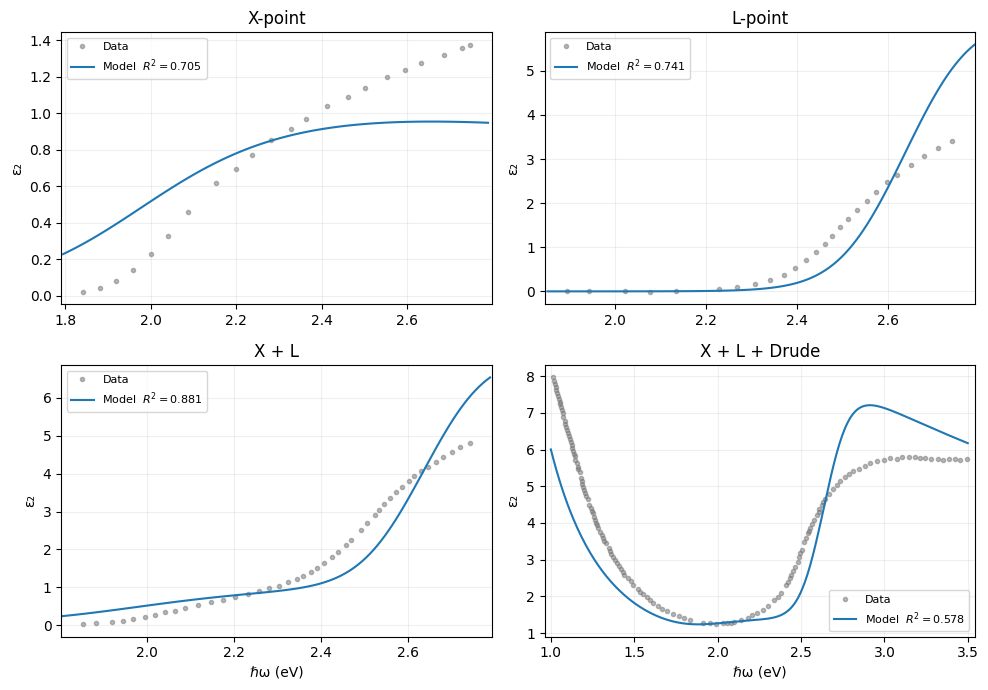

In [ ]:
import os

# ── Energy grid ────────────────────────────────────────────────────────
hw = np.linspace(1.0, 3.5, 300)

# ── Compute raw JDOS contributions ────────────────────────────────────
raw_x = np.array([N_X * P_ratio_sq * jdos_X(w, T) / w**2 for w in hw])
raw_l = np.array([N_L              * jdos_L(w, T) / w**2 for w in hw])

# ── Load digitized data ───────────────────────────────────────────────
data_dir = os.path.dirname(os.path.abspath("__file__"))

def load(fn):
    arr = np.loadtxt(os.path.join(data_dir, fn), delimiter=",", skiprows=1)
    return arr[arr[:, 0].argsort()]

data_X   = load("a_e2_X.txt")
data_L   = load("b_e2_L.txt")
data_XL  = load("c_e2_X_L.txt")
data_XLD = load("d_e2_X_L_Drude.txt")

# ── Fit Scale analytically against X+L data ───────────────────────────
model_at_data = np.interp(data_XL[:, 0], hw, raw_x + raw_l)
Scale = np.dot(data_XL[:, 1], model_at_data) / np.dot(model_at_data, model_at_data)
print(f"Optimal Scale = {Scale:.1f}")

# ── Scaled model curves ──────────────────────────────────────────────
e2_X   = Scale * raw_x
e2_L   = Scale * raw_l
e2_XL  = Scale * (raw_x + raw_l)
e2_XLD = e2_XL + A_drude / hw**3

# ── R² helper ────────────────────────────────────────────────────────
def r_squared(data, model_hw, model_e2):
    mi = np.interp(data[:, 0], model_hw, model_e2)
    ss_res = np.sum((data[:, 1] - mi)**2)
    ss_tot = np.sum((data[:, 1] - np.mean(data[:, 1]))**2)
    return 1 - ss_res / ss_tot if ss_tot > 1e-30 else 0.0

# ── Plot 2×2 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)

panels = [
    (axes[0, 0], "X-point",      data_X,   e2_X),
    (axes[0, 1], "L-point",      data_L,   e2_L),
    (axes[1, 0], "X + L",        data_XL,  e2_XL),
    (axes[1, 1], "X + L + Drude", data_XLD, e2_XLD),
]

for ax, title, dat, model in panels:
    xmin, xmax = dat[:, 0].min() - 0.05, dat[:, 0].max() + 0.05
    
    # Clip model to data range
    mask = (hw >= xmin) & (hw <= xmax)
    
    r2 = r_squared(dat, hw, model)
    ax.plot(dat[:, 0], dat[:, 1], "o", color="0.45", ms=3, alpha=0.5, label="Data")
    ax.plot(hw[mask], model[mask], "-", lw=1.5, label=f"Model  $R^2={r2:.3f}$")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylabel("ε₂")
    ax.set_xlim(xmin, xmax)
    ax.grid(alpha=0.2)

axes[1, 0].set_xlabel("ℏω (eV)")
axes[1, 1].set_xlabel("ℏω (eV)")
fig.tight_layout()
plt.show()